In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
file=pd.read_csv("DATA SET FOR SOLAR FLARE PREDICTION.csv", sep=';')
df=pd.DataFrame(file)
df

,FlareNumber,T_REC,NOAA_AR,QUALITY,Longitude,Latitude,TOTUSJH,TOTBSQ,TOTPOT,TOTUSJZ,...,MEANGBT,MEANGBZ,MEANGBH,MEANJZH,TOTFY,MEANJZD,MEANALP,TOTFX,EPSY,EPSX
0,0,2010-05-01 23:48:00,11064,0,28,15,64.266,2.114200e+09,3.596094e+21,1.204115e+12,...,159.145,160.266,76.708,-0.012005,-349.33,1.697619,-0.031377,285.80,0.1567,-0.1282
1,0,2010-05-02 23:48:00,11064,0,15,16,37.787,1.392500e+09,1.230179e+21,7.821382e+11,...,152.084,158.553,66.027,-0.009381,-216.80,1.823444,-0.032041,7.22,0.1477,-0.0049
2,0,2010-05-03 23:48:00,11063,0,38,16,109.597,2.105100e+09,7.247206e+21,2.210139e+12,...,102.453,102.625,39.314,0.000564,-102.16,-0.383748,0.001854,-470.04,0.0460,0.2118
3,0,2010-05-03 23:48:00,11064,0,2,15,15.710,1.124900e+09,6.198173e+20,4.025928e+11,...,129.121,130.118,48.735,-0.002707,-152.54,1.768766,-0.014741,-123.05,0.1286,0.1037
4,0,2010-05-03 23:48:00,11065,0,16,32,36.136,9.150800e+08,2.181095e+21,9.585403e+11,...,103.869,104.104,31.943,-0.000633,181.19,0.107664,-0.003386,-191.06,-0.1878,0.1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8869,1,2017-09-07 15:00:00,12673,0,58,9,5769.701,7.859000e+10,1.449073e+24,8.285670e+13,...,91.245,104.540,56.592,-0.035639,3494.60,-0.159696,-0.059097,-7805.50,-0.0422,0.0942
8870,1,2017-09-07 23:24:00,12673,0,58,9,5522.014,7.859300e+10,1.307202e+24,7.869333e+13,...,86.031,99.375,53.054,-0.024100,3508.80,-0.065194,-0.040032,-7381.50,-0.0423,0.0891
8871,1,2017-09-08 04:12:00,12673,0,70,9,5562.046,7.901800e+10,1.324064e+24,7.924306e+13,...,88.569,104.689,54.267,-0.021587,3518.20,-0.099056,-0.035159,-7190.80,-0.0422,0.0863
8872,1,2017-09-08 10:48:00,12673,0,70,9,5072.454,7.555800e+10,1.292672e+24,7.544420e+13,...,81.764,97.597,50.309,-0.015436,2879.60,-0.127479,-0.027490,-7216.30,-0.0361,0.0906


In [5]:
df.columns

Index(['FlareNumber', 'T_REC', 'NOAA_AR', 'QUALITY', 'Longitude', 'Latitude',
       'TOTUSJH', 'TOTBSQ', 'TOTPOT', 'TOTUSJZ', 'ABSNJZH', 'SAVNCPP',
       'USFLUX', 'AREA_ACR', 'TOTFZ', 'MEANPOT', 'R_VALUE', 'EPSZ', 'SHRGT45',
       'MEANSHR', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH', 'MEANJZH',
       'TOTFY', 'MEANJZD', 'MEANALP', 'TOTFX', 'EPSY', 'EPSX'],
      dtype='object')

In [6]:
selected_features=['USFLUX','AREA_ACR','TOTPOT','TOTUSJZ','R_VALUE']
x=df[selected_features]
y=df['FlareNumber']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4203)

In [7]:
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
print(classification_report(y_test, y_pred))
cm=confusion_matrix(y_test, y_pred)
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1702
           1       0.83      0.52      0.64        73

    accuracy                           0.98      1775
   macro avg       0.90      0.76      0.81      1775
weighted avg       0.97      0.98      0.97      1775

[[1694    8]
 [  35   38]]


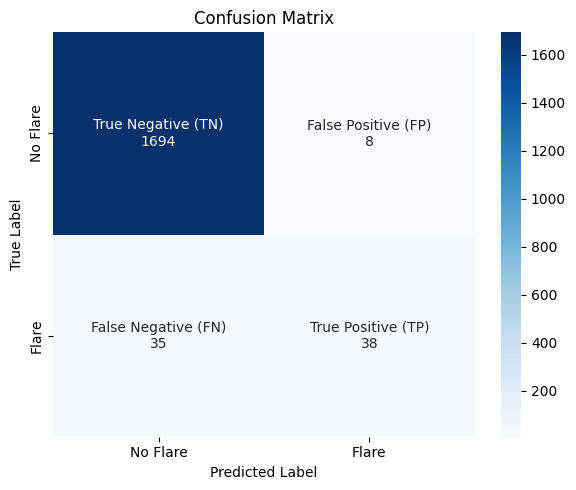

In [9]:
labels = ['No Flare', 'Flare']
group_names = ['True Negative (TN)', 'False Positive (FP)', 
               'False Negative (FN)', 'True Positive (TP)']

group_counts = ["{0:0.0f}".format(value) for row in cm for value in row]
group_labels = [f"{name}\n{count}" for name, count in zip(group_names, group_counts)]
group_labels = [group_labels[:2], group_labels[2:]]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=group_labels, fmt='', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

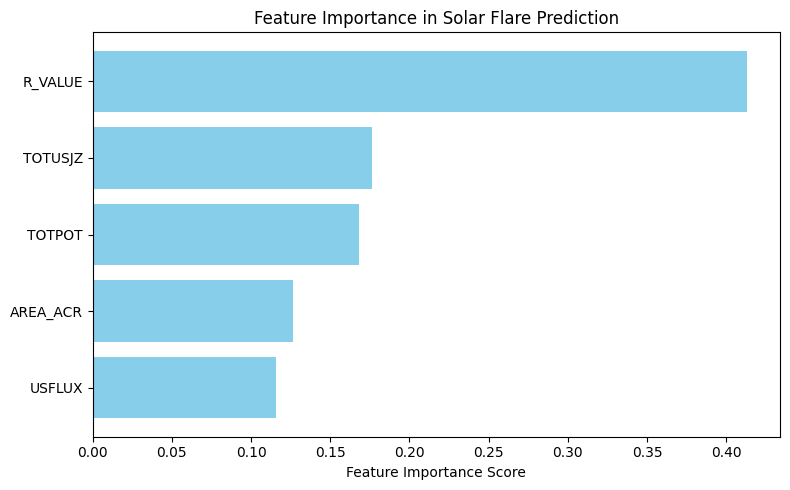

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have a trained Random Forest model
importances = model.feature_importances_
features = ['USFLUX', 'AREA_ACR', 'TOTPOT', 'TOTUSJZ', 'R_VALUE']

# Sort features by importance
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(range(len(importances)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(importances)), [features[i] for i in indices])
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance in Solar Flare Prediction')
plt.tight_layout()
plt.show()


In [11]:
importances = model.feature_importances_
print(importances)

[0.11560372 0.12674507 0.16810873 0.17621655 0.41332594]


In [12]:
len(x)

8874